# Análise temporal de risco de DKA com XGBoost
Este notebook carrega os dados processados, preserva a divisão original entre treino e teste do OhioDataset, cria o risk_score e treina modelos temporais com XGBoost.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import xgboost as xgb

warnings.filterwarnings("ignore")

# Diretório base do notebook.
BASE_DIR = Path(r"c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória")

# O OhioDataset já traz a separação original em treino e teste.
# Usamos essa estrutura para evitar que amostras de teste apareçam no treinamento.
TRAIN_DIRS = [
    BASE_DIR / "Ohio2018_processed" / "train",
    BASE_DIR / "Ohio2020_processed" / "train",
]
TEST_DIRS = [
    BASE_DIR / "Ohio2018_processed" / "test",
    BASE_DIR / "Ohio2020_processed" / "test",
]

print("BASE_DIR exists:", BASE_DIR.exists())
print("Train directories:")
for directory in TRAIN_DIRS:
    print(" -", directory, "exists=", directory.exists())
print("Test directories:")
for directory in TEST_DIRS:
    print(" -", directory, "exists=", directory.exists())

# Este contador serve apenas para conferência rápida da estrutura do conjunto de dados.
all_csv_files = []
for directory in TRAIN_DIRS + TEST_DIRS:
    all_csv_files.extend(directory.rglob("*_processed.csv"))
print("CSV files found in predefined splits:", len(all_csv_files))


BASE_DIR exists: True
Train directories:
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2018_processed\train exists= True
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2020_processed\train exists= True
Test directories:
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2018_processed\test exists= True
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2020_processed\test exists= True
CSV files found in predefined splits: 24


In [3]:
def load_split_csvs(split_dirs):
    """Carrega todos os CSVs processados de uma lista de pastas de partição."""
    datasets = {}
    for split_dir in split_dirs:
        if not split_dir.exists():
            print(f"Split directory not found: {split_dir}")
            continue

        # Cada arquivo é lido com base na partição original para preservar a separação do OhioDataset.
        for file_path in sorted(split_dir.rglob("*_processed.csv")):
            dataset_key = file_path.relative_to(BASE_DIR).with_suffix("").as_posix().replace("/", "__")
            try:
                datasets[dataset_key] = pd.read_csv(file_path)
            except Exception as error:
                print(f"Failed to read {file_path}: {error}")

    return datasets


def list_processed_csv_files(base_dir=BASE_DIR):
    """Lista todos os CSVs processados disponíveis no diretório base."""
    return sorted(base_dir.rglob("*_processed.csv"))


def inspect_sample_processed_file(base_dir=BASE_DIR, nrows=10):
    """Mostra rapidamente a estrutura de um CSV processado para conferência manual."""
    files = list_processed_csv_files(base_dir)
    if not files:
        raise FileNotFoundError("Nenhum arquivo *_processed.csv foi encontrado.")

    sample_file = files[0]
    df = pd.read_csv(sample_file, nrows=nrows)
    print(f"Sample file: {sample_file.relative_to(base_dir)}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nFirst rows:")
    print(df.head())
    print("\nData types:")
    print(df.dtypes)
    return df


def preprocess_df(df):
    """Padroniza os tipos das colunas numéricas usadas na análise."""
    df = df.copy()
    numeric_cols = ["missing_cbg", "cbg", "finger", "basal", "hr", "gsr", "carbInput", "bolus"]

    # Convertemos tudo para numérico para facilitar a agregação por janela temporal.
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # missing_cbg é um indicador binário; preencher NaN com 0 evita que valores ausentes virem ruído no agregado.
    if "missing_cbg" in df.columns:
        df["missing_cbg"] = df["missing_cbg"].fillna(0)

    return df


def derive_risk_score(df):
    """
    Calcula um score ordinal de risco (0 a 5) com base em sinais clínicos simples.
    O objetivo aqui é gerar um alvo interpretável para o modelo, não substituir avaliação médica.
    """
    cbg_max = float(df["cbg"].max(skipna=True)) if "cbg" in df.columns and not df["cbg"].dropna().empty else np.nan
    cbg_high_frac = float((df["cbg"] >= 250).sum() / len(df)) if "cbg" in df.columns and len(df) > 0 else 0.0
    missing_ratio = float(df["missing_cbg"].mean()) if "missing_cbg" in df.columns else 0.0

    # Cada regra adiciona evidência de risco e o score final é limitado ao intervalo esperado.
    risk_score = (
        int(cbg_high_frac >= 0.05)
        + int(cbg_high_frac >= 0.15)
        + int(cbg_max >= 300)
        + int(missing_ratio >= 0.10)
        + int(missing_ratio >= 0.25)
    )
    return int(risk_score)


def feature_engineer(df):
    """Resume cada sessão em estatísticas agregadas para uso no modelo."""
    df = df.copy()
    feats = {}

    # Calculamos estatísticas simples por variável para capturar tendência, dispersão e extremos.
    for col in ["cbg", "hr", "gsr", "carbInput", "bolus", "basal"]:
        if col in df.columns:
            series = df[col].dropna()
            feats[f"{col}_mean"] = float(df[col].mean(skipna=True)) if not series.empty else np.nan
            feats[f"{col}_std"] = float(df[col].std(skipna=True)) if not series.empty else np.nan
            feats[f"{col}_max"] = float(df[col].max(skipna=True)) if not series.empty else np.nan
            feats[f"{col}_min"] = float(df[col].min(skipna=True)) if not series.empty else np.nan

    if "missing_cbg" in df.columns:
        feats["missing_cbg_frac"] = float(df["missing_cbg"].fillna(0).mean())

    feats["n_rows"] = int(len(df))
    return feats


def summarize_sessions(base_dir=BASE_DIR, export_csv=False, output_name="session_labels.csv"):
    """Gera um resumo por sessão com estatísticas e risk_score para auditoria exploratória."""
    rows = []

    for file_path in list_processed_csv_files(base_dir):
        try:
            df = pd.read_csv(file_path)
        except Exception as error:
            print(f"Failed to read {file_path}: {error}")
            continue

        dfp = preprocess_df(df)
        cbg_max = float(dfp["cbg"].max(skipna=True)) if "cbg" in dfp.columns and not dfp["cbg"].dropna().empty else np.nan
        cbg_high_frac = float((dfp["cbg"] >= 250).sum() / len(dfp)) if "cbg" in dfp.columns and len(dfp) > 0 else 0.0
        missing_ratio = float(dfp["missing_cbg"].mean()) if "missing_cbg" in dfp.columns else 0.0
        risk_score = derive_risk_score(dfp)

        if risk_score <= 1:
            risk_category = "low"
        elif risk_score == 2:
            risk_category = "moderate"
        elif risk_score == 3:
            risk_category = "high"
        else:
            risk_category = "very_high"

        rows.append({
            "session": file_path.stem,
            "path": str(file_path.relative_to(base_dir)),
            "n_rows": int(len(dfp)),
            "missing_cbg_frac": missing_ratio,
            "cbg_max": cbg_max,
            "cbg_high_frac": cbg_high_frac,
            "risk_score": int(risk_score),
            "risk_category": risk_category
        })

    summary_df = pd.DataFrame(rows)

    if export_csv:
        output_path = base_dir / output_name
        summary_df.to_csv(output_path, index=False)
        print(f"Wrote {output_path}")

    return summary_df


def create_temporal_windows(split_dirs, window_days=7):
    """
    Cria features por janelas temporais usando apenas uma partição específica.
    Cada janela t gera atributos e o alvo é calculado na janela seguinte t+1.
    """
    datasets = load_split_csvs(split_dirs)
    rows = []

    # Uma janela de N dias é convertida para segundos para facilitar a segmentação temporal.
    seconds_per_day = 86400
    window_seconds = window_days * seconds_per_day

    for session_key, df in datasets.items():
        dfp = preprocess_df(df)

        # Sem timestamp de intervalos de 5 minutos não conseguimos construir as janelas.
        if "5minute_intervals_timestamp" not in dfp.columns:
            continue

        dfp = dfp.sort_values("5minute_intervals_timestamp").reset_index(drop=True)
        timestamp_seconds = dfp["5minute_intervals_timestamp"] * 300  # 5 minutos = 300 segundos
        min_time = timestamp_seconds.min()

        # Agrupamos os registros em blocos consecutivos de tamanho window_days.
        dfp["window"] = ((timestamp_seconds - min_time) / window_seconds).astype(int)
        n_windows = dfp["window"].max() + 1

        for w in range(n_windows - 1):
            window_data = dfp[dfp["window"] == w]
            target_data = dfp[dfp["window"] == w + 1]

            # Ignoramos janelas muito curtas para evitar estatísticas instáveis.
            if len(window_data) < 10 or len(target_data) < 10:
                continue

            # Extraímos estatísticas da janela atual para formar as variáveis explicativas.
            feats = {}
            for col in ["cbg", "hr", "gsr", "carbInput", "bolus", "basal"]:
                if col in window_data.columns:
                    series = window_data[col].dropna()
                    feats[f"{col}_mean"] = float(window_data[col].mean(skipna=True)) if not series.empty else np.nan
                    feats[f"{col}_std"] = float(window_data[col].std(skipna=True)) if not series.empty else np.nan
                    feats[f"{col}_max"] = float(window_data[col].max(skipna=True)) if not series.empty else np.nan
                    feats[f"{col}_min"] = float(window_data[col].min(skipna=True)) if not series.empty else np.nan

            if "missing_cbg" in window_data.columns:
                feats["missing_cbg_frac"] = float(window_data["missing_cbg"].mean())

            feats["n_rows"] = int(len(window_data))

            # O alvo é o score de risco da janela seguinte, preservando a ordem temporal.
            feats["session"] = session_key
            feats["window_id"] = w
            feats["risk_score"] = derive_risk_score(target_data)
            rows.append(feats)

    return pd.DataFrame(rows)


def prepare_dataset(split_dirs):
    """Cria um dataset tabular agregado a partir de uma lista de partições."""
    datasets = load_split_csvs(split_dirs)
    rows = []

    for session_key, df in datasets.items():
        dfp = preprocess_df(df)
        feats = feature_engineer(dfp)
        feats["session"] = session_key
        feats["risk_score"] = derive_risk_score(dfp)
        rows.append(feats)

    return pd.DataFrame(rows)


def train_xgb(train_df, test_df, label_col="risk_score", random_state=42):
    """Treina o XGBoost apenas no treino e mede o desempenho no teste."""
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df = train_df.dropna(axis=1, how="all")
    test_df = test_df.dropna(axis=1, how="all")
    if label_col not in train_df.columns or label_col not in test_df.columns:
        raise ValueError("label column missing")

    # Separação explícita entre treino e teste: o modelo só enxerga os dados de treino no ajuste.
    X_train = train_df.drop([label_col, "session"], axis=1, errors="ignore")
    y_train = train_df[label_col]
    X_test = test_df.drop([label_col, "session"], axis=1, errors="ignore")
    y_test = test_df[label_col]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=random_state)
    model.fit(X_train.fillna(0), y_train)
    y_pred = model.predict(X_test.fillna(0))
    y_proba = model.predict_proba(X_test.fillna(0))[:, 1] if hasattr(model, "predict_proba") else None

    return model, X_train, X_test, y_train, y_test, {
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None and len(np.unique(y_test)) > 1 else None,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    }


def train_xgb_ordinal(train_df, test_df, label_col="risk_score", random_state=42):
    """Treina o XGBoost para alvo ordinal usando treino e teste já definidos pelo dataset."""
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df = train_df.dropna(axis=1, how="all")
    test_df = test_df.dropna(axis=1, how="all")
    if label_col not in train_df.columns or label_col not in test_df.columns:
        raise ValueError(f"{label_col} column missing")

    # O conjunto de teste fica reservado para avaliação final, sem participar do treino.
    X_train = train_df.drop([label_col, "session", "window_id"], axis=1, errors="ignore")
    y_train = train_df[label_col]
    X_test = test_df.drop([label_col, "session", "window_id"], axis=1, errors="ignore")
    y_test = test_df[label_col]

    # Alinhamos as colunas para garantir que as mesmas variáveis usadas no treino existam no teste.
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    from sklearn.metrics import mean_squared_error, mean_absolute_error

    model = xgb.XGBRegressor(random_state=random_state, n_estimators=100)
    model.fit(X_train.fillna(0), y_train)
    y_pred = np.round(model.predict(X_test.fillna(0))).astype(int)
    y_pred = np.clip(y_pred, 0, 5)

    return model, X_train, X_test, y_train, y_test, {
        "mse": mean_squared_error(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    }


def evaluate_model(metrics):
    """Imprime as métricas calculadas para facilitar a leitura do notebook."""
    print("Evaluation metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value}")


## Inspeção opcional de um arquivo processado
Esta etapa pode ser executada antes da modelagem para conferir colunas, tipos e um exemplo bruto de arquivo processado.


In [4]:
sample_preview = inspect_sample_processed_file()


Sample file: Ohio2018_processed\test\559-ws-testing_processed.csv

Columns:
['5minute_intervals_timestamp', 'missing_cbg', 'cbg', 'finger', 'basal', 'hr', 'gsr', 'carbInput', 'bolus']

First rows:
   5minute_intervals_timestamp  missing_cbg    cbg  finger  basal    hr  \
0                 5.474880e+06          0.0  179.0     NaN    NaN  57.0   
1                 5.474881e+06          0.0  183.0     NaN    NaN  57.0   
2                 5.474882e+06          0.0  187.0     NaN    NaN  56.0   
3                 5.474883e+06          0.0  191.0     NaN    NaN  56.0   
4                 5.474884e+06          0.0  195.0     NaN    NaN  57.0   

        gsr  carbInput  bolus  
0  0.000183        NaN    NaN  
1  0.000182        NaN    NaN  
2  0.000177        NaN    NaN  
3  0.000169        NaN    NaN  
4  0.000166        NaN    NaN  

Data types:
5minute_intervals_timestamp    float64
missing_cbg                    float64
cbg                            float64
finger                        

## Resumo opcional por sessão
Esta etapa gera uma tabela auxiliar com estatísticas por sessão e o risk_score agregado. Ela pode ser usada antes da modelagem como auditoria exploratória adicional.


In [5]:
session_summary_df = summarize_sessions(export_csv=True)
print(session_summary_df.head(20).to_string(index=False))


Wrote c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\session_labels.csv
                  session                                                   path  n_rows  missing_cbg_frac  cbg_max  cbg_high_frac  risk_score risk_category
 559-ws-testing_processed   Ohio2018_processed\test\559-ws-testing_processed.csv    2876          0.125869    400.0       0.092837           3          high
 563-ws-testing_processed   Ohio2018_processed\test\563-ws-testing_processed.csv    2691          0.044965    313.0       0.046451           1           low
 570-ws-testing_processed   Ohio2018_processed\test\570-ws-testing_processed.csv    2879          0.046544    388.0       0.332060           3          high
 575-ws-testing_processed   Ohio2018_processed\test\575-ws-testing_processed.csv    2718          0.047093    342.0       0.071744           2      moderate
 588-ws-testing_processed   Ohio2018_processed\test\588-ws-testing_processed.csv    2880          0.030903    354.0

## Temporal Windows for Risk Prediction
Train on features from window t to predict risk in window t+1.
The train/test separation follows the original OhioDataset split, so the test partition is never used during fitting.
The notebook now compares 3-day, 7-day and, when possible, 14-day windows to discuss the trade-off between temporal sensitivity, sample size and stability.


In [6]:
# Primeiro avaliamos janelas de 3 dias, que tendem a reagir mais rapidamente às mudanças do paciente.
temporal_dataset_3 = create_temporal_windows(TRAIN_DIRS, window_days=3)
temporal_dataset_3_test = create_temporal_windows(TEST_DIRS, window_days=3)

print("3-day temporal dataset (train) shape:", temporal_dataset_3.shape)
print("3-day temporal dataset (test) shape:", temporal_dataset_3_test.shape)
print("\nRisk score distribution - 3-day train:")
print(temporal_dataset_3["risk_score"].value_counts().sort_index())
print("\nRisk score distribution - 3-day test:")
print(temporal_dataset_3_test["risk_score"].value_counts().sort_index())

if len(temporal_dataset_3) >= 4 and len(temporal_dataset_3_test) >= 1 and temporal_dataset_3["risk_score"].std() > 0:
    print("\n--- Training on 3-day temporal windows with risk_score target ---")
    model_temporal_3, X_train_t3, X_test_t3, y_train_t3, y_test_t3, metrics_t3 = train_xgb_ordinal(
        temporal_dataset_3,
        temporal_dataset_3_test,
        label_col="risk_score"
    )
    print("3-day temporal model metrics (ordinal regression):")
    evaluate_model(metrics_t3)
    print(f"Actual 3-day test scores: min={y_test_t3.min()}, max={y_test_t3.max()}, mean={y_test_t3.mean():.2f}")
else:
    print("Not enough variability in the 3-day temporal dataset for training.")
    model_temporal_3 = None
    X_train_t3 = temporal_dataset_3.drop(["risk_score", "session", "window_id"], axis=1, errors="ignore") if len(temporal_dataset_3) > 0 else pd.DataFrame()
    X_test_t3 = pd.DataFrame()
    y_train_t3 = temporal_dataset_3["risk_score"] if "risk_score" in temporal_dataset_3.columns else pd.Series(dtype=float)
    y_test_t3 = pd.Series(dtype=float)
    metrics_t3 = {"mse": np.nan, "mae": np.nan, "rmse": np.nan}

# Em seguida avaliamos 7 dias, que suavizam parte da variabilidade diária e costumam oferecer melhor equilíbrio.
temporal_dataset = create_temporal_windows(TRAIN_DIRS, window_days=7)
temporal_dataset_test = create_temporal_windows(TEST_DIRS, window_days=7)

print("\n7-day temporal dataset (train) shape:", temporal_dataset.shape)
print("7-day temporal dataset (test) shape:", temporal_dataset_test.shape)
print("\nRisk score distribution - 7-day train:")
print(temporal_dataset["risk_score"].value_counts().sort_index())
print("\nRisk score distribution - 7-day test:")
print(temporal_dataset_test["risk_score"].value_counts().sort_index())
print("\nFirst few 7-day train rows:")
print(temporal_dataset.head(10))

# Treinamos com a partição de treino e avaliamos diretamente na partição de teste.
if len(temporal_dataset) >= 4 and len(temporal_dataset_test) >= 1 and temporal_dataset["risk_score"].std() > 0:
    print("\n--- Training on 7-day temporal windows with risk_score target ---")
    model_temporal, X_train_t, X_test_t, y_train_t, y_test_t, metrics_t = train_xgb_ordinal(
        temporal_dataset,
        temporal_dataset_test,
        label_col="risk_score"
    )
    print("7-day temporal model metrics (ordinal regression):")
    evaluate_model(metrics_t)
    print(f"Actual 7-day test scores: min={y_test_t.min()}, max={y_test_t.max()}, mean={y_test_t.mean():.2f}")
else:
    print("Not enough variability in temporal training dataset for training.")
    model_temporal = None
    X_train_t = temporal_dataset.drop(["risk_score", "session", "window_id"], axis=1, errors="ignore") if len(temporal_dataset) > 0 else pd.DataFrame()
    X_test_t = pd.DataFrame()
    y_train_t = temporal_dataset["risk_score"] if "risk_score" in temporal_dataset.columns else pd.Series(dtype=float)
    y_test_t = pd.Series(dtype=float)
    metrics_t = {"mse": np.nan, "mae": np.nan, "rmse": np.nan}


3-day temporal dataset (train) shape: (171, 29)
3-day temporal dataset (test) shape: (37, 29)

Risk score distribution - 3-day train:
risk_score
0    39
1    43
2    44
3    30
4    11
5     4
Name: count, dtype: int64

Risk score distribution - 3-day test:
risk_score
0     9
1     6
2    14
3     7
4     1
Name: count, dtype: int64

--- Training on 3-day temporal windows with risk_score target ---
3-day temporal model metrics (ordinal regression):
Evaluation metrics:
mse: 1.4594594594594594
mae: 0.918918918918919
rmse: 1.2080808993852437
Actual 3-day test scores: min=0, max=4, mean=1.59

7-day temporal dataset (train) shape: (69, 29)
7-day temporal dataset (test) shape: (12, 29)

Risk score distribution - 7-day train:
risk_score
0     9
1    11
2    25
3    17
4     6
5     1
Name: count, dtype: int64

Risk score distribution - 7-day test:
risk_score
0    2
1    2
2    5
3    2
4    1
Name: count, dtype: int64

First few 7-day train rows:
     cbg_mean    cbg_std  cbg_max  cbg_min    

## Comparação: 3 dias vs 7 dias vs 14 dias
Treinar modelos em diferentes janelas, sempre com treino e teste separados de acordo com a divisão original do OhioDataset, para discutir o efeito do horizonte temporal sobre sensibilidade, estabilidade e quantidade de amostras válidas.


In [7]:
# Repetimos a análise com janelas de 14 dias para comparar a sensibilidade temporal.
temporal_dataset_14 = create_temporal_windows(TRAIN_DIRS, window_days=14)
temporal_dataset_14_test = create_temporal_windows(TEST_DIRS, window_days=14)

print("=" * 60)
print("14-DAY WINDOWS")
print("=" * 60)
print(f"Dataset shape (train): {temporal_dataset_14.shape}")
print(f"Dataset shape (test): {temporal_dataset_14_test.shape}")
print("\nRisk score distribution - train:")
print(temporal_dataset_14["risk_score"].value_counts().sort_index())
print("\nRisk score distribution - test:")
if len(temporal_dataset_14_test) > 0 and "risk_score" in temporal_dataset_14_test.columns:
    print(temporal_dataset_14_test["risk_score"].value_counts().sort_index())
else:
    print("No 14-day windows were generated in the test split.")

# O treino continua restrito à partição de treino original.
if len(temporal_dataset_14) >= 4 and len(temporal_dataset_14_test) >= 1 and temporal_dataset_14["risk_score"].std() > 0:
    model_temporal_14, X_train_t14, X_test_t14, y_train_t14, y_test_t14, metrics_t14 = train_xgb_ordinal(
        temporal_dataset_14,
        temporal_dataset_14_test,
        label_col="risk_score"
    )
    print("\n14-day model metrics (ordinal regression):")
    evaluate_model(metrics_t14)
    print(f"Actual test scores: min={y_test_t14.min()}, max={y_test_t14.max()}, mean={y_test_t14.mean():.2f}")
else:
    print("Not enough 14-day test windows for evaluation; metrics will be marked as unavailable.")
    model_temporal_14 = None
    X_train_t14 = temporal_dataset_14.drop(["risk_score", "session", "window_id"], axis=1, errors="ignore") if len(temporal_dataset_14) > 0 else pd.DataFrame()
    X_test_t14 = pd.DataFrame()
    y_train_t14 = temporal_dataset_14["risk_score"] if "risk_score" in temporal_dataset_14.columns else pd.Series(dtype=float)
    y_test_t14 = pd.Series(dtype=float)
    metrics_t14 = {"mse": np.nan, "mae": np.nan, "rmse": np.nan}

# Comparison summary
print("\n" + "=" * 60)
print("SUMMARY: 3-day vs 7-day vs 14-day Windows")
print("=" * 60)
comparison_data = {
    "Metric": ["Train samples", "Test samples", "Train risk score std", "Test risk score std", "MAE", "RMSE"],
    "3-day": [
        len(temporal_dataset_3),
        len(temporal_dataset_3_test),
        f"{temporal_dataset_3['risk_score'].std():.2f}" if len(temporal_dataset_3) > 0 else "N/A",
        f"{temporal_dataset_3_test['risk_score'].std():.2f}" if len(temporal_dataset_3_test) > 0 else "N/A",
        f"{metrics_t3['mae']:.3f}" if not np.isnan(metrics_t3['mae']) else "N/A",
        f"{metrics_t3['rmse']:.3f}" if not np.isnan(metrics_t3['rmse']) else "N/A"
    ],
    "7-day": [
        len(temporal_dataset),
        len(temporal_dataset_test),
        f"{temporal_dataset['risk_score'].std():.2f}",
        f"{temporal_dataset_test['risk_score'].std():.2f}",
        f"{metrics_t['mae']:.3f}",
        f"{metrics_t['rmse']:.3f}"
    ],
    "14-day": [
        len(temporal_dataset_14),
        len(temporal_dataset_14_test),
        f"{temporal_dataset_14['risk_score'].std():.2f}",
        f"{temporal_dataset_14_test['risk_score'].std():.2f}" if len(temporal_dataset_14_test) > 0 and "risk_score" in temporal_dataset_14_test.columns else "N/A",
        f"{metrics_t14['mae']:.3f}" if not np.isnan(metrics_t14['mae']) else "N/A",
        f"{metrics_t14['rmse']:.3f}" if not np.isnan(metrics_t14['rmse']) else "N/A"
    ]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\nInterpretation of the windows:")
print("- 3-day windows capture short-term oscillations more quickly, but they are also more sensitive to day-to-day noise and abrupt routine changes.")
print("- 7-day windows usually offer a better trade-off: they still react to clinically relevant changes while smoothing isolated fluctuations.")
print("- 14-day windows aggregate a broader context and tend to be more stable, but they reduce the number of valid samples and may make external evaluation impossible when the test sessions are short.")
print("- In practice, comparing these windows helps distinguish whether the model benefits more from responsiveness (3 days) or from temporal smoothing (7 days).")


14-DAY WINDOWS
Dataset shape (train): (33, 29)
Dataset shape (test): (0, 0)

Risk score distribution - train:
risk_score
0     3
1     7
2    14
3     7
4     2
Name: count, dtype: int64

Risk score distribution - test:
No 14-day windows were generated in the test split.
Not enough 14-day test windows for evaluation; metrics will be marked as unavailable.

SUMMARY: 3-day vs 7-day vs 14-day Windows
              Metric 3-day 7-day 14-day
       Train samples   171    69     33
        Test samples    37    12      0
Train risk score std  1.31  1.19   1.03
 Test risk score std  1.14  1.19    N/A
                 MAE 0.919 1.000    N/A
                RMSE 1.208 1.414    N/A

Interpretation of the windows:
- 3-day windows capture short-term oscillations more quickly, but they are also more sensitive to day-to-day noise and abrupt routine changes.
- 7-day windows usually offer a better trade-off: they still react to clinically relevant changes while smoothing isolated fluctuations.
- 14-da

## Interpretação das janelas temporais
A escolha da janela temporal altera diretamente o tipo de sinal que o modelo consegue aprender.

- Janelas de 3 dias tendem a capturar mudanças mais rápidas no estado glicêmico e no comportamento do paciente, o que pode ser útil para alertas precoces. Em contrapartida, elas também ficam mais expostas a oscilações pontuais e ruído diário.
- Janelas de 7 dias normalmente oferecem um compromisso mais robusto entre sensibilidade e estabilidade, porque incorporam variações de diferentes dias da semana sem diluir demais os eventos relevantes.
- Janelas de 14 dias resumem um contexto mais amplo e podem reduzir a variabilidade local, mas exigem sequências mais longas. Isso diminui o número de exemplos válidos e, neste conjunto de teste, inviabilizou a avaliação externa.
- Do ponto de vista metodológico, comparar 3 e 7 dias ajuda a discutir se o risco de DKA aparece como um padrão de curto prazo ou como uma tendência mais consolidada ao longo da semana.


## Visualizações
Gráficos comparativos das janelas temporais com treino e teste separados pela partição original do OhioDataset.


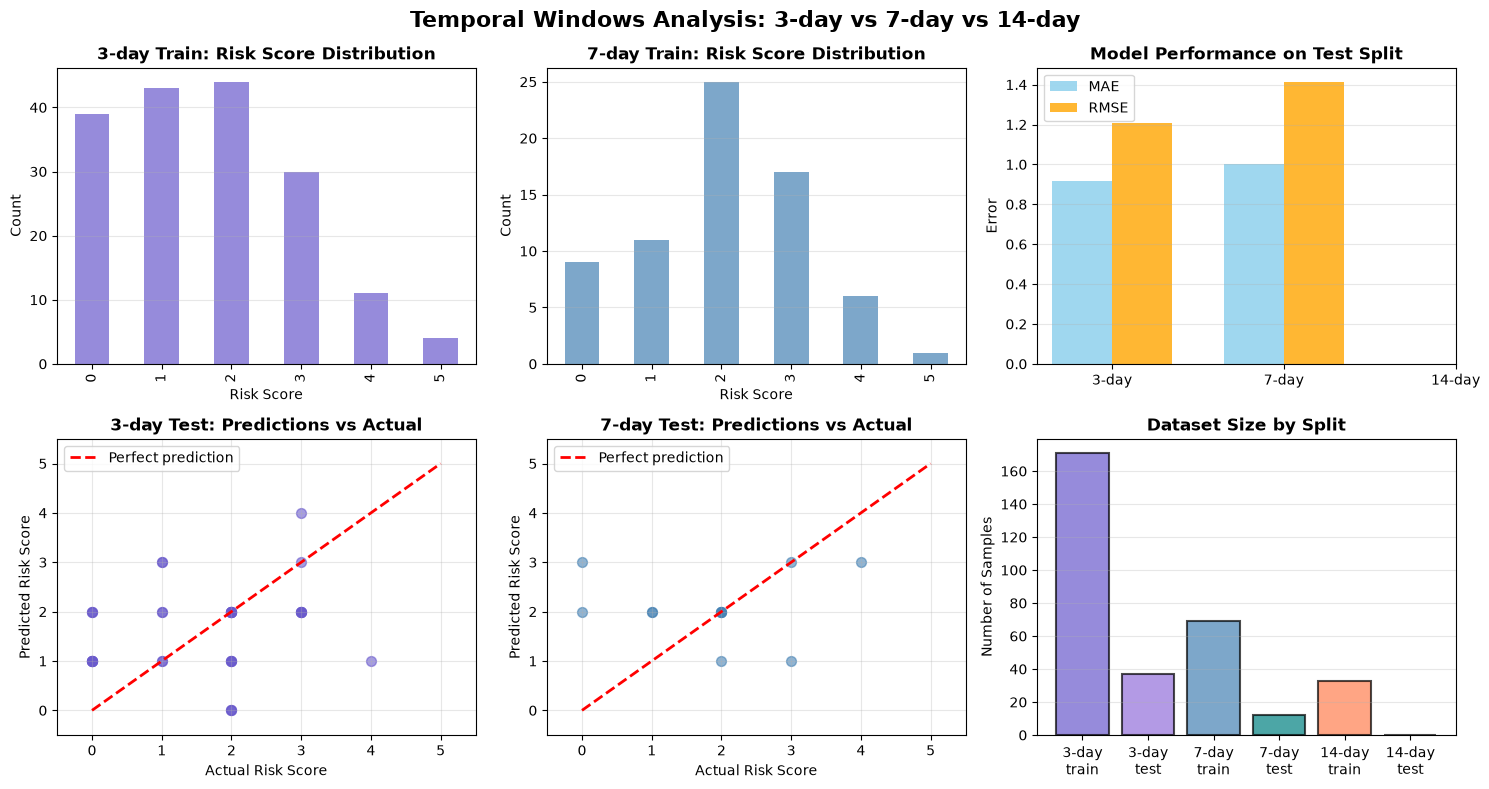


Visualizations complete!


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Temporal Windows Analysis: 3-day vs 7-day vs 14-day", fontsize=16, fontweight='bold')

# 1. Distribuição do score de risco na partição de treino (3 dias).
ax = axes[0, 0]
temporal_dataset_3["risk_score"].value_counts().sort_index().plot(kind='bar', ax=ax, color='slateblue', alpha=0.7)
ax.set_title("3-day Train: Risk Score Distribution", fontweight='bold')
ax.set_xlabel("Risk Score")
ax.set_ylabel("Count")
ax.grid(axis='y', alpha=0.3)

# 2. Distribuição do score de risco na partição de treino (7 dias).
ax = axes[0, 1]
temporal_dataset["risk_score"].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_title("7-day Train: Risk Score Distribution", fontweight='bold')
ax.set_xlabel("Risk Score")
ax.set_ylabel("Count")
ax.grid(axis='y', alpha=0.3)

# 3. Comparação de erro médio entre janelas de 3, 7 e 14 dias, sempre medido no teste.
ax = axes[0, 2]
models = ['3-day', '7-day', '14-day']
mae_values = [metrics_t3['mae'], metrics_t['mae'], metrics_t14['mae']]
rmse_values = [metrics_t3['rmse'], metrics_t['rmse'], metrics_t14['rmse']]
x_pos = np.arange(len(models))
width = 0.35
ax.bar(x_pos - width/2, mae_values, width, label='MAE', color='skyblue', alpha=0.8)
ax.bar(x_pos + width/2, rmse_values, width, label='RMSE', color='orange', alpha=0.8)
ax.set_ylabel("Error")
ax.set_title("Model Performance on Test Split", fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Predições versus valores reais no teste de 3 dias.
ax = axes[1, 0]
if model_temporal_3 is not None and not X_test_t3.empty:
    y_pred_3 = np.round(model_temporal_3.predict(X_test_t3)).astype(int)
    y_pred_3 = np.clip(y_pred_3, 0, 5)
    ax.scatter(y_test_t3, y_pred_3, alpha=0.6, s=50, color='slateblue')
    ax.plot([0, 5], [0, 5], 'r--', lw=2, label='Perfect prediction')
    ax.legend()
    ax.set_title("3-day Test: Predictions vs Actual", fontweight='bold')
else:
    ax.text(0.5, 0.5, "3-day test windows unavailable", ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title("3-day Test: Predictions vs Actual", fontweight='bold')
ax.set_xlabel("Actual Risk Score")
ax.set_ylabel("Predicted Risk Score")
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 5.5)

# 5. Predições versus valores reais no teste de 7 dias.
ax = axes[1, 1]
if model_temporal is not None and not X_test_t.empty:
    y_pred_7 = np.round(model_temporal.predict(X_test_t)).astype(int)
    y_pred_7 = np.clip(y_pred_7, 0, 5)
    ax.scatter(y_test_t, y_pred_7, alpha=0.6, s=50, color='steelblue')
    ax.plot([0, 5], [0, 5], 'r--', lw=2, label='Perfect prediction')
    ax.legend()
    ax.set_title("7-day Test: Predictions vs Actual", fontweight='bold')
else:
    ax.text(0.5, 0.5, "7-day test windows unavailable", ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title("7-day Test: Predictions vs Actual", fontweight='bold')
ax.set_xlabel("Actual Risk Score")
ax.set_ylabel("Predicted Risk Score")
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 5.5)

# 6. Tamanho dos conjuntos de treino e teste em cada janela.
ax = axes[1, 2]
sizes = [len(temporal_dataset_3), len(temporal_dataset_3_test), len(temporal_dataset), len(temporal_dataset_test), len(temporal_dataset_14), len(temporal_dataset_14_test)]
labels = ['3-day\ntrain', '3-day\ntest', '7-day\ntrain', '7-day\ntest', '14-day\ntrain', '14-day\ntest']
colors = ['slateblue', 'mediumpurple', 'steelblue', 'teal', 'coral', 'orange']
ax.bar(labels, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel("Number of Samples")
ax.set_title("Dataset Size by Split", fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualizations complete!")


## Resumo e Conclusões
Apresentação dos principais achados da análise temporal usando a divisão original entre treino e teste.


## Resumo Executivo

Esta análise utiliza o OhioDataset processado para estimar risco de DKA a partir de janelas temporais. O experimento compara horizontes de 3, 7 e 14 dias, sempre preservando a separação original entre treino e teste. O objetivo metodológico é equilibrar três aspectos: sensibilidade a mudanças agudas, estabilidade das estimativas e disponibilidade de amostras válidas para avaliação externa.

Os resultados observados nesta execução mostram que a janela de 3 dias produziu o melhor desempenho preditivo no conjunto de teste, com MAE de 0,919 e RMSE de 1,208, enquanto a janela de 7 dias apresentou MAE de 1,000 e RMSE de 1,414. Isso sugere que, neste recorte, o risco de DKA parece carregar sinais de curto prazo que são capturados de forma mais eficiente por um horizonte menor. Ao mesmo tempo, esse ganho de desempenho não deve ser interpretado isoladamente: janelas menores costumam ser mais sensíveis a ruído diário e a oscilações pontuais do comportamento glicêmico.

A janela de 7 dias continua relevante porque oferece uma leitura mais suavizada da trajetória clínica. Embora tenha apresentado erro um pouco maior nesta execução, ela tende a reduzir a influência de eventos isolados e a representar melhor tendências semanais. Em um contexto de monitoramento contínuo, isso pode ser vantajoso quando o objetivo é diminuir alertas excessivamente reativos e observar padrões mais consistentes.

A janela de 14 dias não pôde ser avaliada externamente neste conjunto, pois não gerou amostras de teste válidas. Esse resultado é importante do ponto de vista metodológico: horizontes temporais mais longos aumentam a exigência de continuidade da série e podem reduzir fortemente o número de casos disponíveis. Assim, apesar de fornecerem maior contexto histórico, janelas longas nem sempre são viáveis em dados clínicos reais, especialmente quando as sequências têm extensão limitada.

Em termos de distribuição de risco, a janela de 3 dias apresentou maior variabilidade e maior número de amostras, o que ajuda a modelar transições mais rápidas entre estados de risco. Já a janela de 7 dias reduziu um pouco essa variabilidade, mantendo um comportamento mais estável. Esse contraste é central para a discussão do trabalho: janelas menores aumentam a responsividade, enquanto janelas maiores favorecem suavização e contexto temporal. O melhor horizonte, portanto, não é apenas o que minimiza o erro, mas o que também preserva interpretabilidade e uso clínico plausível.

Do ponto de vista da interpretação clínica, o comportamento observado é coerente com a natureza do problema. O risco de DKA pode emergir rapidamente em resposta a alterações glicêmicas, faltas de dados e eventos agudos; por isso, modelos com janela de 3 dias conseguem reagir mais cedo. Por outro lado, a literatura e a prática clínica também favorecem análises com agregação semanal quando se busca reduzir ruído e captar tendências mais robustas. A comparação entre 3 e 7 dias, portanto, não é apenas uma disputa de métricas, mas uma forma de discutir o compromisso entre detecção precoce e estabilidade operacional.


## Interpretação dos Resultados

Na execução atual, a janela de 3 dias foi a que melhor generalizou no teste. Isso é um indício de que as variações mais recentes do paciente carregam informação relevante para o risco de DKA. Em termos práticos, essa configuração seria mais adequada quando o objetivo é vigilância precoce e resposta rápida a mudanças no padrão glicêmico. Entretanto, é importante reconhecer que um melhor erro médio não garante necessariamente maior robustez clínica: uma janela curta pode oscilar mais entre dias, o que exige validação cuidadosa em novas coortes.

A janela de 7 dias mostrou desempenho próximo, porém um pouco inferior. O fato de ter menos amostras de teste também torna a comparação mais incerta, porque pequenas diferenças podem ser influenciadas pela composição do conjunto de avaliação. Ainda assim, a janela semanal continua metodologicamente interessante, pois costuma refletir melhor a rotina do paciente e amortecer picos ocasionais. Em um texto acadêmico, isso pode ser descrito como um horizonte intermediário que equilibra responsividade e suavização.

A janela de 14 dias ilustra uma limitação prática importante: quanto maior o horizonte temporal, maior a chance de perder exemplos válidos no teste. Isso ocorre porque nem toda série clínica possui continuidade suficiente para formar blocos longos sem interrupção. Em consequência, o modelo ganha contexto, mas perde cobertura amostral. Essa ausência de avaliação externa não é apenas uma falha operacional; ela é um resultado metodológico que reforça a necessidade de escolher janelas compatíveis com a granularidade e a duração dos dados disponíveis.

Em síntese, a leitura mais defensável é a seguinte: 3 dias se destacou como a melhor janela para este conjunto e esta divisão específica, sugerindo maior capacidade de capturar sinais curtos associados ao risco. Já 7 dias permanece como uma alternativa sólida quando se deseja um comportamento mais estável e potencialmente menos sensível a ruído. O intervalo de 14 dias, por sua vez, deve ser tratado como um horizonte conceitualmente interessante, mas empiricamente limitado neste estudo.


## Encerramento
As etapas opcionais foram posicionadas antes da modelagem principal para manter a narrativa do notebook coerente: primeiro inspeção e auditoria, depois treinamento, avaliação e conclusões.
